# mmBERT-small Learning Curves

This notebook analyzes how the performance of **mmBERT-small** changes as the amount of available training data increases. The validation set remains unchanged, while separate models are trained on progressively larger subsets of the training data.

Each learning-curve point is initialized from the same pretrained `jhu-clsp/mmBERT-small` checkpoint and trained with an identical configuration to ensure a fair comparison across dataset sizes. The experiment reports training accuracy, validation accuracy, generalization gap, and training runtime for each subset. The test split is excluded from this analysis and reserved for final model evaluation.

In [1]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from datasets import DatasetDict, load_dataset
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import accuracy_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

from peft import LoraConfig, TaskType, get_peft_model


## Load the training and validation data

In [8]:
from datasets import load_from_disk

dataset = load_from_disk(
    "hf-dataset-3class-full"
)

train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "human": split["label"].count(0),
            "ai": split["label"].count(1),
            "ai_assisted": split["label"].count(2),
            "total": len(split),
        }
        for name, split in {
            "train": train_dataset,
            "validation": validation_dataset,
            "test": test_dataset,
        }.items()
    ]
).set_index("split")

split_summary

,human,ai,ai_assisted,total
split,,,,
train,8342,8324,8320,24986
validation,971,967,968,2906
test,914,912,911,2737


## Experiment Configuration



The experiment evaluates mmBERT-small using **1%, 5%,12%, 17.5%, 25%, 50%, and 100%** of the available training data. The maximum sequence length is set to **512 tokens**.

In [96]:
RANDOM_STATE = 17
NUM_TRAIN_EPOCHS = 3

TRAIN_FRACTIONS = np.asarray(
    [0.01,0.05,0.12, 0.175, 0.25, 0.50, 1.00]
)

set_seed(RANDOM_STATE)

MODEL_NAME = "jhu-clsp/mmBERT-small"
MAX_LENGTH = 512

## 1. Tokenization

Load the mmBERT-small tokenizer and convert the text dataset into model-ready token sequences using a maximum length of 512 tokens and dynamic batch padding.

In [98]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


curve_dataset = DatasetDict(
    {
        "train": train_dataset,
        "validation": validation_dataset,
    }
)

columns_to_remove = [
    column
    for column in train_dataset.column_names
    if column != "label"
]

tokenized_dataset = curve_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing",
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2906
    })
})

## 2. Nested Training Order

Create a reproducible class-balanced ordering of the training samples so that larger learning-curve subsets contain all samples from the smaller subsets.

In [99]:
def build_stratified_order(
    labels,
    seed,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    rng = np.random.default_rng(
        seed
    )

    classes = np.unique(
        labels
    )

    class_indices = {}

    for class_id in classes:
        indices = np.flatnonzero(
            labels == class_id
        )

        rng.shuffle(
            indices
        )

        class_indices[
            class_id
        ] = indices.tolist()

    class_proportions = {
        class_id:
            len(class_indices[class_id])
            / len(labels)
        for class_id in classes
    }

    selected = {
        class_id: 0
        for class_id in classes
    }

    order = []

    for step in range(
        len(labels)
    ):
        available = [
            class_id
            for class_id in classes
            if selected[class_id]
            < len(
                class_indices[class_id]
            )
        ]

        next_class = max(
            available,
            key=lambda class_id:
                (
                    class_proportions[
                        class_id
                    ]
                    * (step + 1)
                    - selected[
                        class_id
                    ]
                ),
        )

        index_position = (
            selected[
                next_class
            ]
        )

        order.append(
            class_indices[
                next_class
            ][index_position]
        )

        selected[
            next_class
        ] += 1

    return np.asarray(
        order,
        dtype=np.int64,
    )


training_order = build_stratified_order(
    train_dataset["label"],
    seed=RANDOM_STATE,
)

## 3. Training Subsets

Define the training-set sizes used for the learning-curve experiment at 1%, 12%, 25%, 50%, and 100% of the available training data.

In [100]:
train_sizes = np.rint(
    TRAIN_FRACTIONS
    * len(train_dataset)
).astype(np.int64)

train_sizes = np.unique(
    np.clip(
        train_sizes,
        2,
        len(train_dataset),
    )
)

train_sizes[-1] = len(
    train_dataset
)


subset_summary = pd.DataFrame(
    {
        "training_samples":
            train_sizes,

        "training_fraction":
            train_sizes
            / len(train_dataset),
    }
)

subset_summary.style.format(
    {
        "training_fraction":
            "{:.1%}",
    }
)

,training_samples,training_fraction
0,250,1.0%
1,1249,5.0%
2,2998,12.0%
3,4373,17.5%
4,6246,25.0%
5,12493,50.0%
6,24986,100.0%


## 4. Model Initialization

Define a fresh mmBERT-small sequence-classification model for the three target classes: Human, AI, and AI-assisted.

In [56]:
ID_TO_LABEL = {
    0: "HUMAN",
    1: "AI",
    2: "AI_ASSISTED",
}

LABEL_TO_ID = {
    "HUMAN": 0,
    "AI": 1,
    "AI_ASSISTED": 2,
}


def create_mmbert_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    )

## 5. Experiment Output

Create directories for learning-curve results, checkpoints, and figures, and define the output paths used throughout the experiment.

In [57]:
OUTPUT_DIR = Path(
    "learning-curve-mmbert-small"
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    / "checkpoints"
)

RESULTS_DIR = (
    OUTPUT_DIR
    / "results"
)

FIGURES_DIR = (
    OUTPUT_DIR
    / "figures"
)

RESULTS_PATH = (
    RESULTS_DIR
    / "mmbert-small-learning-curve.csv"
)

for directory in [
    CHECKPOINT_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    f"Training epochs per point: "
    f"{NUM_TRAIN_EPOCHS}"
)

print(
    f"Results file: "
    f"{RESULTS_PATH}"
)

Training epochs per point: 1
Results file: learning-curve-mmbert-small/results/mmbert-small-learning-curve.csv


## 6. Learning-Curve Experiment

Train a fresh mmBERT-small model on each training subset and measure training accuracy, validation accuracy, generalization gap, and training runtime.

In [39]:
import time

learning_curve_rows = []

use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

for sample_count in train_sizes:
    sample_count = int(sample_count)

    train_indices = training_order[:sample_count]

    train_subset = tokenized_dataset["train"].select(
        train_indices.tolist()
    )

    set_seed(RANDOM_STATE)

    model = create_mmbert_model()

    training_args = TrainingArguments(
        output_dir=str(
            CHECKPOINT_DIR / f"samples-{sample_count}"
        ),
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=0.01,
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="epoch",
        bf16=use_bf16,
        fp16=(
            torch.cuda.is_available()
            and not use_bf16
        ),
        report_to="none",
        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        processing_class=tokenizer,
        data_collator=data_collator,
    )

    print(
        f"\nTraining with {sample_count:,} samples"
    )

    start_time = time.perf_counter()

    trainer.train()

    runtime = (
        time.perf_counter()
        - start_time
    )

    train_output = trainer.predict(
        train_subset
    )

    validation_output = trainer.predict(
        tokenized_dataset["validation"]
    )

    training_accuracy = accuracy_score(
        train_output.label_ids,
        np.argmax(
            train_output.predictions,
            axis=1,
        ),
    )

    validation_accuracy = accuracy_score(
        validation_output.label_ids,
        np.argmax(
            validation_output.predictions,
            axis=1,
        ),
    )

    learning_curve_rows.append(
        {
            "training_samples": sample_count,
            "training_fraction":
                sample_count / len(train_dataset),
            "training_accuracy":
                training_accuracy,
            "validation_accuracy":
                validation_accuracy,
            "generalization_gap":
                training_accuracy
                - validation_accuracy,
            "training_runtime_seconds":
                runtime,
        }
    )

    print(
        f"Training accuracy: "
        f"{training_accuracy:.2%}; "
        f"validation accuracy: "
        f"{validation_accuracy:.2%}"
    )

    del trainer
    del model
    del train_subset
    del train_output
    del validation_output

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


mmbert_learning_curve = pd.DataFrame(
    learning_curve_rows
)

mmbert_learning_curve

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 250 samples
{'loss': '1.143', 'grad_norm': '97.55', 'learning_rate': '6.25e-07', 'epoch': '1'}
{'train_runtime': '2.543', 'train_samples_per_second': '98.31', 'train_steps_per_second': '12.58', 'train_loss': '1.143', 'epoch': '1'}
Training accuracy: 74.40%; validation accuracy: 62.73%


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 2,998 samples
{'loss': '0.4436', 'grad_norm': '47.18', 'learning_rate': '5.333e-08', 'epoch': '1'}
{'train_runtime': '29.53', 'train_samples_per_second': '101.5', 'train_steps_per_second': '12.7', 'train_loss': '0.4436', 'epoch': '1'}
Training accuracy: 95.90%; validation accuracy: 90.95%


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 12,493 samples
{'loss': '0.3308', 'grad_norm': '44.13', 'learning_rate': '1.28e-08', 'epoch': '1'}
{'train_runtime': '122.2', 'train_samples_per_second': '102.2', 'train_steps_per_second': '12.78', 'train_loss': '0.3308', 'epoch': '1'}
Training accuracy: 97.39%; validation accuracy: 94.53%


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 24,986 samples
{'loss': '0.2831', 'grad_norm': '0.0001423', 'learning_rate': '6.402e-09', 'epoch': '1'}
{'train_runtime': '245', 'train_samples_per_second': '102', 'train_steps_per_second': '12.75', 'train_loss': '0.2831', 'epoch': '1'}
Training accuracy: 97.59%; validation accuracy: 94.84%


,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,250,0.010006,0.744000,0.627323,0.116677,2.839430
1,2998,0.119987,0.958973,0.909498,0.049475,29.817627
2,6246,0.249980,0.968460,0.925671,0.042789,61.662284
3,12493,0.500000,0.973905,0.945286,0.028620,122.497789
4,24986,1.000000,0.975907,0.948383,0.027524,245.283513


## 7. Learning-Curve Results

Collect and format the performance measurements obtained for each training-set size.

In [74]:
mmbert_learning_curve = pd.DataFrame(
    learning_curve_rows
)

mmbert_learning_curve.style.format(
    {
        "training_fraction":
            "{:.1%}",

        "training_accuracy":
            "{:.2%}",

        "validation_accuracy":
            "{:.2%}",

        "generalization_gap":
            "{:.2%}",

        "training_runtime_seconds":
            "{:,.1f}",
    }
)

,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,250,1.0%,40.40%,37.54%,2.86%,4.5
1,1249,5.0%,93.35%,86.55%,6.81%,12.9
2,2499,10.0%,95.68%,89.81%,5.86%,25.1
3,2998,12.0%,95.90%,90.95%,4.95%,29.8
4,4373,17.5%,96.59%,91.95%,4.65%,43.5
5,6246,25.0%,96.85%,92.57%,4.28%,61.7
6,12493,50.0%,97.39%,94.53%,2.86%,122.5
7,24986,100.0%,97.59%,94.84%,2.75%,245.3


## 8. Learning-Curve Visualization

Plot training and validation accuracy against the percentage of training data used to visualize how mmBERT-small performance changes with dataset size.

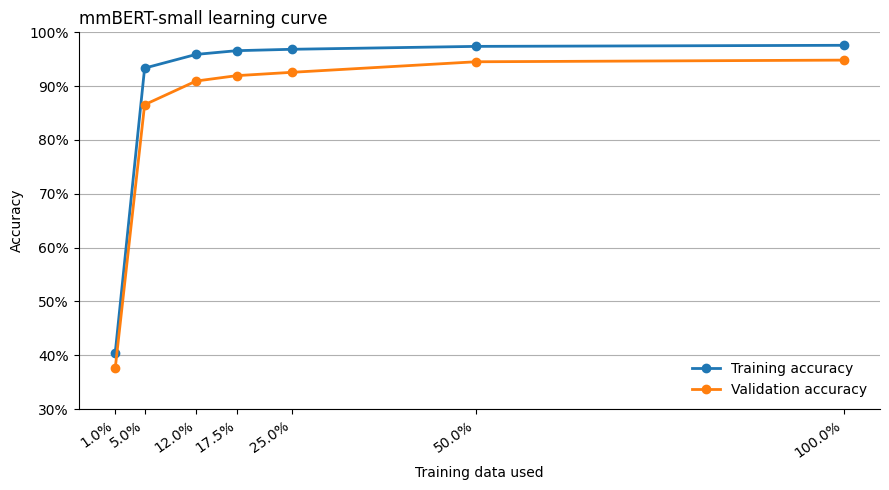

Saved figure to learning-curve-mmbert-small/figures/mmbert-small-learning-curve.svg


In [91]:
mmbert_learning_curve = (
    mmbert_learning_curve
    .sort_values("training_fraction")
    .reset_index(drop=True)
)

x_percent = (
    mmbert_learning_curve[
        "training_fraction"
    ].to_numpy()
    * 100
)

training_accuracy = (
    mmbert_learning_curve[
        "training_accuracy"
    ].to_numpy()
)

validation_accuracy = (
    mmbert_learning_curve[
        "validation_accuracy"
    ].to_numpy()
)

fig, ax = plt.subplots(
    figsize=(7.2, 4.8)
)

ax.plot(
    x_percent,
    training_accuracy,
    marker="o",
    linewidth=2,
    label="Training accuracy",
)

ax.plot(
    x_percent,
    validation_accuracy,
    marker="o",
    linewidth=2,
    label="Validation accuracy",
)

ax.set_xscale(
    "log"
)

ax.set_xticks(
    x_percent,
    [
        (
            f"{fraction:.1f}%\n"
            f"{samples:,}"
        )
        for fraction, samples
        in zip(
            x_percent,
            mmbert_learning_curve[
                "training_samples"
            ],
        )
    ],
)

lower_limit = max(
    0.5,
    min(
        training_accuracy.min(),
        validation_accuracy.min(),
    )
    - 0.03,
)

ax.set_ylim(
    lower_limit,
    1.005,
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_xlabel(
    "Training data used"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "mmBERT-small learning curve",
    loc="left",
)

ax.grid(
    axis="y",
    linewidth=0.8,
)

ax.spines[
    ["top", "right"]
].set_visible(
    False
)

ax.legend(
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

FIGURE_PATH = (
    FIGURES_DIR
    / "mmbert-small-learning-curve.svg"
)

fig.savefig(
    FIGURE_PATH,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure to "
    f"{FIGURE_PATH}"
)